In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv("Salary_dataset.csv")
data = data.drop(columns=['Unnamed: 0'])
print(data.head())

   YearsExperience   Salary
0              1.2  39344.0
1              1.4  46206.0
2              1.6  37732.0
3              2.1  43526.0
4              2.3  39892.0


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [18]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


In [3]:
X = data['YearsExperience'].values.reshape(-1, 1)
y = data['Salary'].values.reshape(-1, 1)

In [5]:
X_mean = np.mean(X)
X_std = np.std(X)
X = (X - X_mean) / X_std


y_mean = np.mean(y)
y_std = np.std(y)
y = (y - y_mean) / y_std

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(X_test)


In [12]:
y_pred

array([[ 1.47613439],
       [-0.16712845],
       [ 0.98665184],
       [-0.0272763 ],
       [-0.76150012],
       [-0.58668493]])

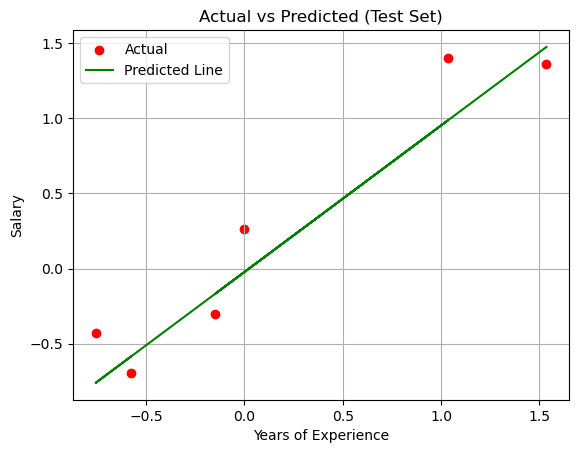

In [16]:
plt.scatter(X_test, y_test, color='red', label='Actual')
plt.plot(X_test, y_pred, color='green', label='Predicted Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Actual vs Predicted (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
print("\nscikit-learn Test Set Metrics:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.5f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.5f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")


scikit-learn Test Set Metrics:
MAE: 0.23323
MSE: 0.06859
RMSE: 0.26189564518156905
R2 Score: 0.9024461774180499
